# Calcolo della f0 su tutto il dataset

In [110]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
import ipywidgets as widgets
import json
import emcee

In [111]:
%matplotlib widget
plt.close('all')

Abbiamo alcune opzioni da confrontare per il calcolo della f0, tra cui:
- primo picco dello spettro di potenza
- gcd approx
- regressione lineare
- bayesiano

In [112]:
def get_f0_first_peak(peak_freqs, freqs, spectrum):
    return peak_freqs[0] if len(peak_freqs) > 0 else None

def get_f0_from_gcd(peak_freqs):
    if len(peak_freqs) < 2:
        return None  # Non abbastanza picchi per calcolare la f0

    peak_freqs = peak_freqs[:5]

    fmin = np.min(peak_freqs) / 2
    fmax = np.min(peak_freqs)
    candidates = np.arange(fmin, fmax, 0.05)

    best_f0 = None
    best_score = float('inf')

    for f0 in candidates:
        residuals = [f/f0 - round(f/ f0) for f in peak_freqs if f > f0]
        residual = sum(residuals)

        if residual < best_score and np.round(peak_freqs / f0).min() > 0:  # Assicurati che ci siano armoniche valide
            best_score = residual
            best_f0 = f0
    
    return best_f0

def get_f0_linear_regression(peak_freqs):

    peak_freqs = peak_freqs[:5]

    if len(peak_freqs) < 2:
        return None  # Non abbastanza picchi per la regressione lineare
    x = np.arange(1, len(peak_freqs) + 1)
    y = peak_freqs
    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0] # m è la pendenza (f0 stimata), c è l'intercetta
    return m  # La pendenza della retta è la f0 stimata


In [73]:

def get_limiti_prior(observed_freqs):
    f_min = np.min(observed_freqs) * 0.2
    f_max = np.min(observed_freqs) * 3

    log_sigma_min = np.log(1e-5)   # 0.1 Hz
    log_sigma_max = np.log(100)   # 100 Hz

    log_uniform = -np.log(f_max - f_min)

    ns_max = len(observed_freqs) # massimo numero di picchi osservati inizialmente

    return f_min, f_max, log_sigma_min, log_sigma_max, log_uniform

# def init_bayesian(observed_freqs, nwalkers=50):
#     f_min, f_max, log_sigma_min, log_sigma_max, log_uniform = get_limiti_prior(observed_freqs)

#     n_max = len(observed_freqs)

#     ns = np.arange(1, n_max + 1) # indice per gestire i picchi

#     log_norm_const = -0.5 * np.log(2.0 * np.pi)

#     def log_prob_vect(theta_batch):
#         theta_batch = np.atleast_2d(theta_batch) # assicura che sia 2D anche se viene passato un singolo punto

#         f0 = theta_batch[:, 0] # primo parametro: f0
#         log_sigma = theta_batch[:, 1] # secondo parametro: log(sigma)
#         q = theta_batch[:, 2] # terzo parametro: q (mixing coefficient)

#         logp = np.full(theta_batch.shape[0], -np.inf, dtype=float) # inizializza logp con -inf per i casi non validi

#         valid = (
#             (f0 > f_min) & (f0 < f_max) &
#             (log_sigma > log_sigma_min) & (log_sigma < log_sigma_max) &
#             (q > 0.0) & (q < 1.0)
#         )

#         if not np.any(valid):
#             return logp

#         f0v = f0[valid]
#         log_sigmav = log_sigma[valid]
#         qv = q[valid]

#         sigma = np.exp(log_sigmav)

#         # expected shape: (Wv, N)
#         expected = f0v[:, None] * ns[None, :] # genera le frequenze attese per ogni armonica data f0

#         # residuals shape: (Wv, K, N)
#         residuals = observed_freqs[None, :, None] - expected[:, None, :] # calcola i residui tra frequenze osservate e attese

#         # log N(f_k | n f0, sigma^2), shape: (Wv, K, N)
#         log_gauss = (
#             -0.5 * (residuals / sigma[:, None, None]) ** 2
#             - np.log(sigma)[:, None, None]
#             + log_norm_const
#         )

#         # log media su n: log(1/N * sum_n ...)
#         log_harm = sp.special.logsumexp(log_gauss, axis=2) - np.log(n_max)  # (Wv, K)

#         # miscela q * harmonic + (1-q) * uniforme in log-space
#         log_mix = np.logaddexp(
#             np.log(qv)[:, None] + log_harm,
#             np.log1p(-qv)[:, None] + log_uniform
#         )  # (Wv, K)

#         logp[valid] = np.sum(log_mix, axis=1)
#         return logp
    
#     ndim = 3  # f0, log_sigma, q

#     p0 = np.column_stack([
#     np.random.normal(observed_freqs[0], observed_freqs[0] * 0.8, nwalkers),
#     np.random.normal(np.log(1), 0.5, nwalkers),
#     np.random.uniform(0.5, 1.0, nwalkers)
#     ])

#     sampler = emcee.EnsembleSampler(
#         nwalkers,
#         ndim,
#         log_prob_vect,
#         vectorize=True,
#     )

#     return sampler, p0

# def get_f0_bayesian(peak_freqs, nwalkers=50, nsteps=100):
#     try:
#         peak_freqs = np.array(peak_freqs[:10])
#         peak_freqs = peak_freqs
#         sampler, p0 = init_bayesian(peak_freqs, nwalkers=nwalkers)
#         state = sampler.run_mcmc(p0, nsteps, progress=False)
#         samples = sampler.get_chain(discard=nsteps//4, flat=True)

#         f0_samples = samples[:, 0]
#         f0_estimate = np.median(f0_samples)

#         q_samples = samples[:, 2]
#         q_estimate = np.median(q_samples)

#         #print(f"F0 stimata: {f0_estimate:.2f} Hz, q stimato: {q_estimate:.2f}")

#         return f0_estimate

#     except Exception as e:
#         print(f"Errore nell'inferenza bayesiana: {e}")
#         return None

# def get_f0_bayesian_map(peak_freqs):

#     # metodo bayesiano che cerca solo il max della posterior, invece di campionare.
#     # molto veloce rispetto a emcee

#     f_min, f_max, log_sigma_min, log_sigma_max, log_uniform = get_limiti_prior(peak_freqs)

#     n_max = len(peak_freqs)

#     ns = np.arange(1, n_max + 1)

#     log_norm_const = -0.5 * np.log(2.0 * np.pi)

#     def log_prob_vect(theta_batch):
#         theta_batch = np.atleast_2d(theta_batch)

#         f0 = theta_batch[:, 0]
#         log_sigma = theta_batch[:, 1]
#         q = theta_batch[:, 2]

#         logp = np.full(theta_batch.shape[0], -np.inf, dtype=float)

#         valid = (
#             (f0 > f_min) & (f0 < f_max) &
#             (log_sigma > log_sigma_min) & (log_sigma < log_sigma_max) &
#             (q > 0.0) & (q < 1.0)
#         )

#         if not np.any(valid):
#             return logp

#         f0v = f0[valid]
#         log_sigmav = log_sigma[valid]
#         qv = q[valid]

#         sigma = np.exp(log_sigmav)

#         # expected shape: (Wv, N)
#         expected = f0v[:, None] * ns[None, :]

#         # residuals shape: (Wv, K, N)
#         residuals = peak_freqs[None, :, None] - expected[:, None, :]

#         # log N(f_k | n f0, sigma^2), shape: (Wv, K, N)
#         log_gauss = (
#             -0.5 * (residuals / sigma[:, None, None]) ** 2
#             - np.log(sigma)[:, None, None]
#             + log_norm_const
#         )

#         # log media su n: log(1/N * sum_n ...)
#         log_harm = sp.special.logsumexp(log_gauss, axis=2) - np.log(n_max)  # (Wv, K)

#         # miscela q * harmonic + (1-q) * uniforme in log-space
#         log_mix = np.logaddexp(
#             np.log(qv)[:, None] + log_harm,
#             np.log1p(-qv)[:, None] + log_uniform
#         )  # (Wv, K)

#         logp[valid] = np.sum(log_mix, axis=1)
#         return logp

#     log_prob = lambda theta: log_prob_vect(theta[None, :])[0]
#     result = sp.optimize.minimize(lambda theta: -log_prob(theta), x0=[peak_freqs[0], np.log(50), 0.5], method='Nelder-Mead')
#     print(f"F0 stimata (MAP): {result.x[0]:.4f} +- {result.x[1]:.4f} Hz. q stimato: {result.x[2]:.4f}")
#     return result.x[0]


In [76]:
from scipy.special import logsumexp


def get_f0_bayesian_map(peak_freqs):

    f_min, f_max, log_sigma_min, log_sigma_max, log_uniform = get_limiti_prior(peak_freqs)

    # Parametri delle armoniche
    ns = np.arange(1, 21)   # Consideriamo le prime 20 armoniche
    P_n_log = -np.log(len(ns))     # Probabilità uniforme P(n)
    U_log = log_uniform # Probabilità uniforme del rumore
    q_min = 1e-3
    q_max = 1.0 - 1e-3

    def log_prob(theta):

        f0, log_sigma, q = theta
        sigma = np.exp(log_sigma)

        if not (f_min < f0 < f_max and log_sigma_min < log_sigma < log_sigma_max and q_min < q < q_max):
            return -1e15

        total_log_likelihood = 0.0

        for fk in peak_freqs:
            # Calcoliamo log(N(fk | n*f0, sigma)) per ogni n in modo stabile
            # Formula: -0.5 * ((x-mu)/sigma)^2 - log(sigma * sqrt(2*pi))
            log_gaussians = -0.5 * ((fk - ns * f0) / sigma)**2 - log_sigma - 0.5 * np.log(2 * np.pi)
            
            # Somma delle armoniche: log(sum(P_n * Gauss))
            log_p_harmonics = logsumexp(log_gaussians + P_n_log)

            # Miscela: log(q * p_harm + (1-q) * p_unif)
            # logaddexp(a, b) calcola log(exp(a) + exp(b))
            log_p_total = np.logaddexp(np.log(q) + log_p_harmonics, np.log(1 - q) + U_log)
            
            total_log_likelihood += log_p_total

        return total_log_likelihood
    
    f_start = peak_freqs[0]  
    sigma_start = np.log(1.0)

    # Seed data-driven di q per evitare che il MAP resti bloccato su un valore fisso.
    q_grid = np.linspace(q_min, q_max, 25)
    q_scores = [log_prob([f_start, sigma_start, q]) for q in q_grid]
    q_start = float(q_grid[int(np.argmax(q_scores))])

    x0 = [f_start, sigma_start, q_start]

    res = sp.optimize.minimize(
        lambda t: -log_prob(t),
        x0=x0,
        method='L-BFGS-B',
        bounds=[
            (f_min, f_max),
            (log_sigma_min, log_sigma_max),
            (q_min, q_max)
        ],
        options={'maxiter': 300}
    )

    f0_map, log_sigma_map, q_map = res.x
    q_map = float(np.clip(q_map, q_min, q_max))
    print(f"MAP Singolo -> F0: {f0_map:.2f}Hz, Sigma: {np.exp(log_sigma_map):.5f}Hz, q: {q_map:.8f}")

    return f0_map, q_map

In [71]:
base_dir = "dati_processati"
peak_file = "spettri_10_periodi_peaks.json"

filepath = os.path.join(base_dir, peak_file)

with open(filepath, 'r') as f:
    peaks_dict = json.load(f)


In [77]:
# calcola f0 per ogni campione usando i diversi metodi
f0_results = {}
bayesian_q_results = {}
for sample, data in peaks_dict.items():
    print(f"Processing {sample}...")
    freqs = np.array(data["peaks"]['frequencies'])
    mags = np.array(data["peaks"]['magnitudes'])

    bayesian_map_result = get_f0_bayesian_map(freqs)
    if bayesian_map_result is None:
        bayesian_map_f0 = None
        bayesian_map_q = None
    else:
        bayesian_map_f0, bayesian_map_q = bayesian_map_result

    f0_results[sample] = {
        'first_peak': get_f0_first_peak(freqs, freqs, mags),
        'gcd': get_f0_from_gcd(freqs),
        'linear_regression': get_f0_linear_regression(freqs),
        #'bayesian': get_f0_bayesian(freqs),
        'bayesian_map': bayesian_map_f0
    }
    bayesian_q_results[sample] = bayesian_map_q

Processing Nota_1...
MAP Singolo -> F0: 1568.63Hz, Sigma: 0.00001Hz, q: 0.01533466
Processing Nota_2...
MAP Singolo -> F0: 1490.68Hz, Sigma: 0.00001Hz, q: 0.14348063
Processing Nota_3...
MAP Singolo -> F0: 330.81Hz, Sigma: 0.00001Hz, q: 0.98687561
Processing Nota_4...
MAP Singolo -> F0: 169.54Hz, Sigma: 0.00001Hz, q: 0.07334813
Processing Nota_5...
MAP Singolo -> F0: 224.72Hz, Sigma: 0.00001Hz, q: 0.18942860
Processing Nota_6...
MAP Singolo -> F0: 467.38Hz, Sigma: 0.00001Hz, q: 0.99772252
Processing Nota_7...
MAP Singolo -> F0: 176.15Hz, Sigma: 0.00001Hz, q: 0.23568277
Processing Nota_8...
MAP Singolo -> F0: 784.31Hz, Sigma: 0.00001Hz, q: 0.99899997
Processing Nota_9...
MAP Singolo -> F0: 156.73Hz, Sigma: 0.00005Hz, q: 0.37451332
Processing Nota_10...
MAP Singolo -> F0: 233.63Hz, Sigma: 0.00001Hz, q: 0.99899999
Processing Nota_11...
MAP Singolo -> F0: 1403.51Hz, Sigma: 0.00001Hz, q: 0.20923383
Processing Nota_12...
MAP Singolo -> F0: 1179.36Hz, Sigma: 0.00001Hz, q: 0.99899997
Processin

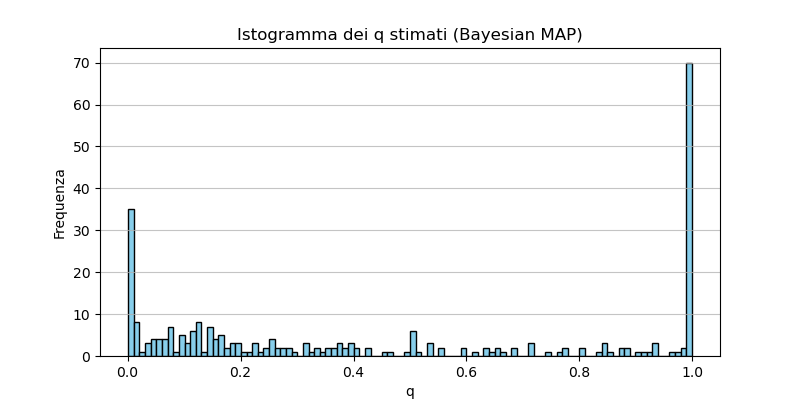

Campioni con q stimato > 0.95:
Nota_3: q = 0.98687561
Nota_6: q = 0.99772252
Nota_8: q = 0.99899997
Nota_10: q = 0.99899999
Nota_12: q = 0.99899997
Nota_14: q = 0.99773477
Nota_15: q = 0.99830855
Nota_19: q = 0.99344839
Nota_21: q = 0.99900000
Nota_22: q = 0.99899999
Nota_24: q = 0.99899873
Nota_26: q = 0.99899998
Nota_28: q = 0.99899999
Nota_41: q = 0.99899999
Nota_43: q = 0.99870242
Nota_44: q = 0.99900000
Nota_47: q = 0.99193083
Nota_55: q = 0.97582153
Nota_58: q = 0.99860584
Nota_68: q = 0.99893836
Nota_72: q = 0.99900000
Nota_84: q = 0.99899999
Nota_86: q = 0.99899998
Nota_89: q = 0.99900000
Nota_92: q = 0.99899079
Nota_105: q = 0.98355640
Nota_109: q = 0.99899235
Nota_111: q = 0.99899999
Nota_113: q = 0.99550553
Nota_116: q = 0.99864531
Nota_119: q = 0.99894227
Nota_120: q = 0.99833740
Nota_123: q = 0.99899999
Nota_125: q = 0.99900000
Nota_127: q = 0.99900000
Nota_131: q = 0.99747954
Nota_132: q = 0.99899001
Nota_139: q = 0.99792396
Nota_140: q = 0.99900000
Nota_141: q = 0.999000

In [78]:
# istogramma delle q_map stimate con il metodo bayesiano
bayesian_qs = [q for q in bayesian_q_results.values() if q is not None]
plt.figure(figsize=(8, 4))
plt.hist(bayesian_qs, bins=100, color='skyblue', edgecolor='black')
plt.title('Istogramma dei q stimati (Bayesian MAP)')
plt.xlabel('q')
plt.ylabel('Frequenza')
plt.grid(axis='y', alpha=0.75)
plt.show()

# stampa i file in cui q è maggiore di 0.95
print("Campioni con q stimato > 0.95:")
for sample, q in bayesian_q_results.items():
    if q is not None and q > 0.95:
        print(f"{sample}: q = {q:.8f}") 


In [79]:
for sample, results in f0_results.items():
    print(f"{sample}:")
    for method, f0 in results.items():
        print(f"  {method}: {f0}")

Nota_1:
  first_peak: 1568.627450980392
  gcd: 815.6637254901675
  linear_regression: 1872.9411764705883
  bayesian_map: 1568.6274509771583
Nota_2:
  first_peak: 1490.6832298136646
  gcd: 781.3916149067995
  linear_regression: 1484.72049689441
  bayesian_map: 1490.6832298087952
Nota_3:
  first_peak: 330.8063404548587
  gcd: 220.50317022744187
  linear_regression: 430.0482425913162
  bayesian_map: 330.8063404498597
Nota_4:
  first_peak: 169.53642384105962
  gcd: 91.41821192052943
  linear_regression: 174.83443708609278
  bayesian_map: 169.53642358616207
Nota_5:
  first_peak: 224.71910112359552
  gcd: 147.40955056179575
  linear_regression: 220.2247191011236
  bayesian_map: 224.71910112252885
Nota_6:
  first_peak: 467.3807205452775
  gcd: 311.54036027265647
  linear_regression: 467.3807205452774
  bayesian_map: 467.38072135044763
Nota_7:
  first_peak: 176.1467889908257
  gcd: 116.22339449541126
  linear_regression: 174.38532110091745
  bayesian_map: 176.1467889860149
Nota_8:
  first_peak

In [80]:
note_freqs = {}
for octave in range(1, 7):  # 1..8
    for i, note in enumerate(["DO", "DO#", "RE", "RE#", "MI", "FA", "FA#", "SOL", "SOL#", "LA", "LA#", "SI"]):
        freq = 16.35 * (2 ** octave) * (2 ** (i / 12))
        note_freqs[f"{note}{octave}"] = freq

print("Frequenze delle note:")
for note, freq in sorted(note_freqs.items()):
    print(f"  {note}: {freq:.2f} Hz")

Frequenze delle note:
  DO#1: 34.64 Hz
  DO#2: 69.29 Hz
  DO#3: 138.58 Hz
  DO#4: 277.16 Hz
  DO#5: 554.31 Hz
  DO#6: 1108.62 Hz
  DO1: 32.70 Hz
  DO2: 65.40 Hz
  DO3: 130.80 Hz
  DO4: 261.60 Hz
  DO5: 523.20 Hz
  DO6: 1046.40 Hz
  FA#1: 46.24 Hz
  FA#2: 92.49 Hz
  FA#3: 184.98 Hz
  FA#4: 369.96 Hz
  FA#5: 739.92 Hz
  FA#6: 1479.83 Hz
  FA1: 43.65 Hz
  FA2: 87.30 Hz
  FA3: 174.60 Hz
  FA4: 349.19 Hz
  FA5: 698.39 Hz
  FA6: 1396.78 Hz
  LA#1: 58.26 Hz
  LA#2: 116.53 Hz
  LA#3: 233.06 Hz
  LA#4: 466.12 Hz
  LA#5: 932.24 Hz
  LA#6: 1864.47 Hz
  LA1: 54.99 Hz
  LA2: 109.99 Hz
  LA3: 219.98 Hz
  LA4: 439.96 Hz
  LA5: 879.91 Hz
  LA6: 1759.83 Hz
  MI1: 41.20 Hz
  MI2: 82.40 Hz
  MI3: 164.80 Hz
  MI4: 329.60 Hz
  MI5: 659.19 Hz
  MI6: 1318.38 Hz
  RE#1: 38.89 Hz
  RE#2: 77.77 Hz
  RE#3: 155.55 Hz
  RE#4: 311.10 Hz
  RE#5: 622.19 Hz
  RE#6: 1244.39 Hz
  RE1: 36.70 Hz
  RE2: 73.41 Hz
  RE3: 146.82 Hz
  RE4: 293.64 Hz
  RE5: 587.27 Hz
  RE6: 1174.54 Hz
  SI1: 61.73 Hz
  SI2: 123.46 Hz
  SI3: 246

In [81]:
types = [
    "first_peak",
    "gcd",
    "linear_regression",
    #"bayesian",
    "bayesian_map"
]

# separa i risultati per metodo e rimiovi i None
method_results = {method: [] for method in types}
for sample, results in f0_results.items():
    for method in types:
        method_results[method].append(results[method])

# rimuovi i None values
for method in types:
    method_results[method] = [freq for freq in method_results[method] if freq is not None]


# binning dei risultati nelle note più vicine
def find_closest_note(freq, note_freqs):
    closest_note = None
    min_diff = float('inf')
    for note, note_freq in note_freqs.items():
        diff = abs(freq - note_freq)
        if diff < min_diff:
            min_diff = diff
            closest_note = note
    return closest_note

binned_results = {method: [] for method in types}
for method in types:
    for freq in method_results[method]:
        if freq is not None:
            closest_note = find_closest_note(freq, note_freqs)
            binned_results[method].append(closest_note)
        else:
            binned_results[method].append(None)



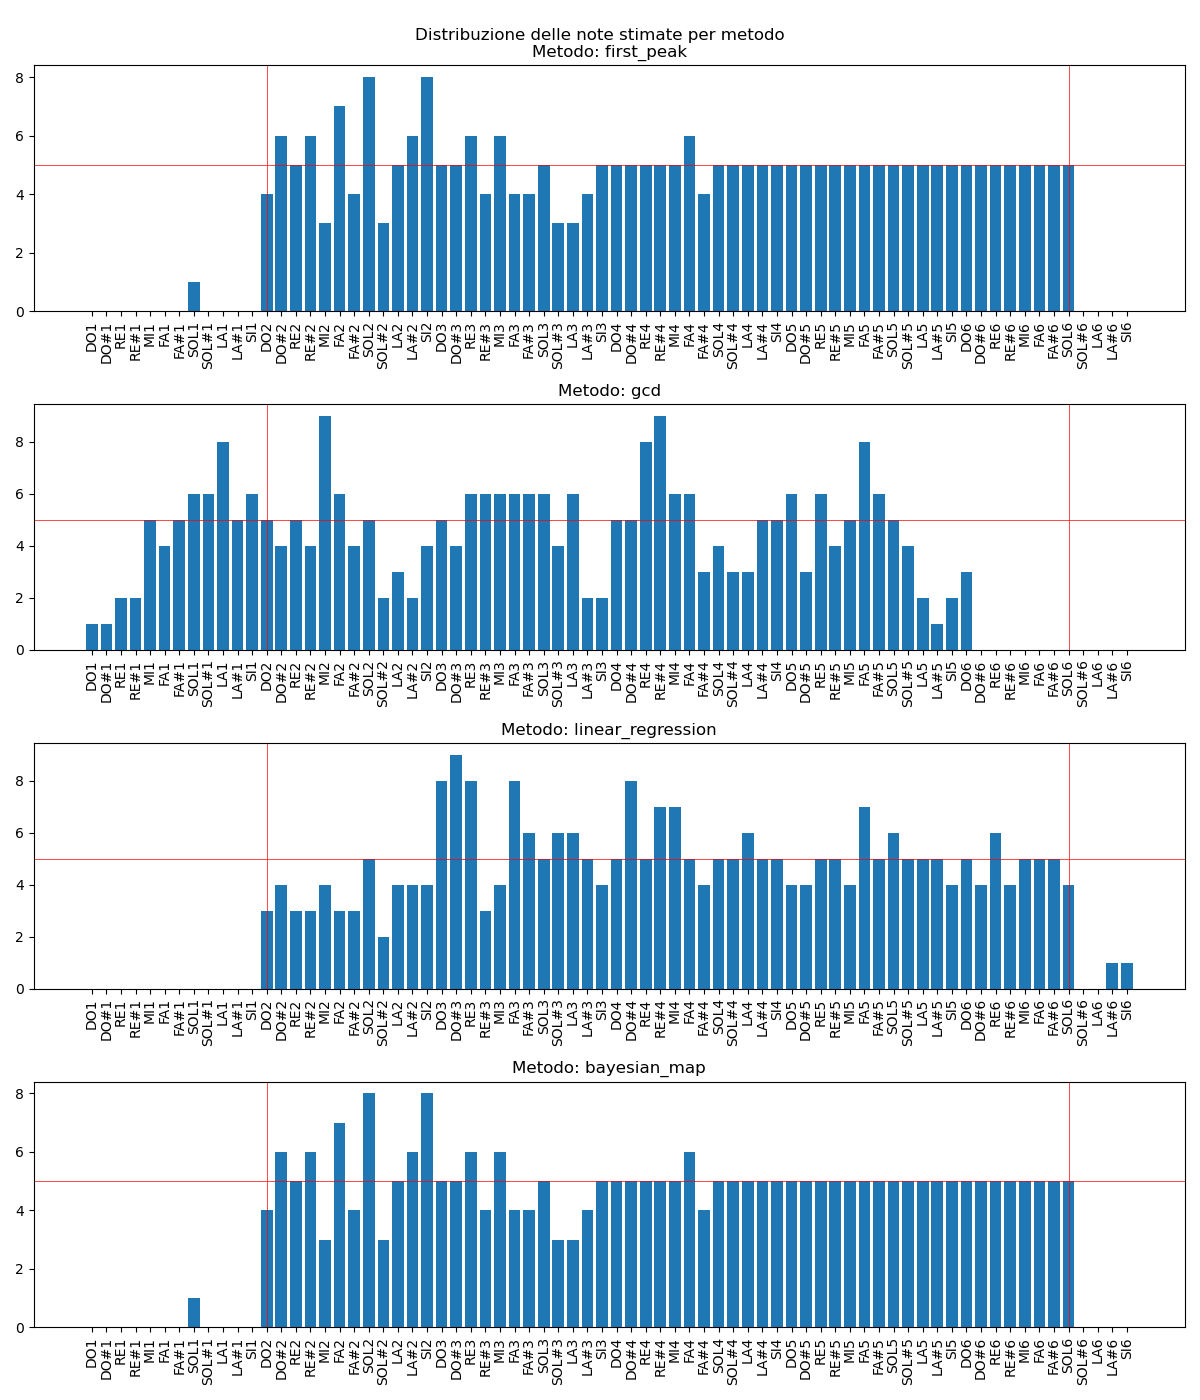

In [82]:
ordered_notes = list(note_freqs.keys())
fig, axs = plt.subplots(len(types), 1, figsize=(12, 14))

fig.suptitle("Distribuzione delle note stimate per metodo")

for i, method in enumerate(types):
    counts = [binned_results[method].count(note) for note in ordered_notes]
    axs[i].bar(np.arange(len(ordered_notes)), counts, width=0.8)
    axs[i].set_title(f"Metodo: {method}")
    axs[i].set_xticks(np.arange(len(ordered_notes)))
    axs[i].set_xticklabels(ordered_notes, rotation=90)
    axs[i].axhline(5, color='red', linewidth=0.5)
    if "DO2" in ordered_notes:
        axs[i].axvline(ordered_notes.index("DO2"), color='red', linewidth=0.5)
    if "SOL6" in ordered_notes:
        axs[i].axvline(ordered_notes.index("SOL6"), color='red', linewidth=0.5)


plt.tight_layout()
plt.show()


In [48]:
#stampa i nomi dei file da cui provengono tutte le note la cui barra nel grafico è più alta di 5 per il bayesian_map
threshold = 5
method = "bayesian_map"
print(f"Note con più di {threshold} occorrenze per il metodo {method}:")
for note in ordered_notes:  
    count = binned_results[method].count(note)
    if count > threshold:
        print(f"  {note}: {count} occorrenze")
        # stampa i nomi dei file che hanno questa nota
        for sample, results in f0_results.items():
            if results[method] is not None and find_closest_note(results[method], note_freqs) == note:
                print(f"    - {sample}")    


Note con più di 5 occorrenze per il metodo bayesian_map:
  DO#2: 6 occorrenze
    - Nota_53
    - Nota_115
    - Nota_119
    - Nota_173
    - Nota_205
    - Nota_206
  RE#2: 6 occorrenze
    - Nota_40
    - Nota_80
    - Nota_157
    - Nota_188
    - Nota_191
    - Nota_248
  FA2: 7 occorrenze
    - Nota_23
    - Nota_88
    - Nota_122
    - Nota_140
    - Nota_159
    - Nota_224
    - Nota_238
  SOL2: 8 occorrenze
    - Nota_25
    - Nota_37
    - Nota_57
    - Nota_127
    - Nota_136
    - Nota_145
    - Nota_153
    - Nota_235
  LA#2: 6 occorrenze
    - Nota_33
    - Nota_70
    - Nota_121
    - Nota_146
    - Nota_228
    - Nota_270
  SI2: 8 occorrenze
    - Nota_17
    - Nota_30
    - Nota_42
    - Nota_134
    - Nota_167
    - Nota_225
    - Nota_241
    - Nota_274
  RE3: 6 occorrenze
    - Nota_19
    - Nota_41
    - Nota_44
    - Nota_109
    - Nota_114
    - Nota_204
  MI3: 6 occorrenze
    - Nota_4
    - Nota_59
    - Nota_99
    - Nota_149
    - Nota_169
    - Nota_217
  FA